<a href="https://colab.research.google.com/github/rprofeta81/IMU-based-Human-Activity-Classification/blob/main/IMU_based_Human_Activity_Recognition_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Machine Learning-based Classification

 I will be training the neural network to understand the certain IMU data with the appropriate lables for the microcontroller to process in real-time and decipher what human activity is being done.

 Hardware:
  

1.   STM32L476RG
2.   BMI270 (IMU Sensor)
3.   LSM6DSV16X (another IMU Sensor)
4.   OLED Screen from kit

Software:


1.   Google Colab
2.   VSCODE
3.   Platform IO





The layout should be the same as the previous sine-wave example, except the data is IMU-based human activity from this website (https://addbiomechanics.org/download_data.html).

The 6 labels they used are:
1 = walking upstairs, 2 = walking downstairs, 3 = walking, 4 = sitting, 5 = standing, 6 = jogging.

I am going to try and create my own neural network based on these labels and I will test them later.

**Import libraries**

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd

In [62]:
# Define the directory and file name for the C header file
C_HEADER_DIR = "../deployment/include/"
MODEL_FILE_NAME = "enhanced_activity_model"

**Load the CSV file**

Ensure that the csv file is uploaded to the google colab folder area.

In [63]:
# Load the CSV file
df = pd.read_csv('/IMU-based Human Activity Recignition Dataset.csv')

#2. Extract features and target labels
#features ax, ay, az, gx, gy, gz
x = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']].values
#activity labels 1, 2, 3, 4, 5, 6
y = df['activity'].values

# Since tf prefers 0-indexed classes for categorigal classification, shifting from 1-6 to 0-5 is best
y = y - 1

#Define split ratios and partiiton the data
  # 70% train, 20% test, 10% validation
SAMPLE_SIZE = len(x)
train_ratio = 0.7
test_ratio = 0.2
validation_ratio = 0.1

#Shuffle the dataset randomly
RANDOM_SEED = 25
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

shuffle_inices = np.random.permutation(len(x))
x = x[shuffle_inices]
y = y[shuffle_inices]

train_end = int(train_ratio * SAMPLE_SIZE)
test_end = int((train_ratio + test_ratio) * SAMPLE_SIZE)

X_train, X_test, X_validate = np.split(x, [train_end, test_end])
y_train, y_test, y_validate = np.split(y, [train_end, test_end])

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Validate size: {len(X_validate)}")

Train size: 11186
Test size: 3195
Validate size: 1599


**Standardization of data helps the neural network perform much better**

In [64]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test and validation data using the same scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)
X_validate_scaled = scaler.transform(X_validate)

print("Features scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"X_validate_scaled shape: {X_validate_scaled.shape}")

Features scaled successfully!
X_train_scaled shape: (11186, 6)
X_test_scaled shape: (3195, 6)
X_validate_scaled shape: (1599, 6)


**2 x 3 grid to see the exact range and frequency distribution of every single IMU axis**

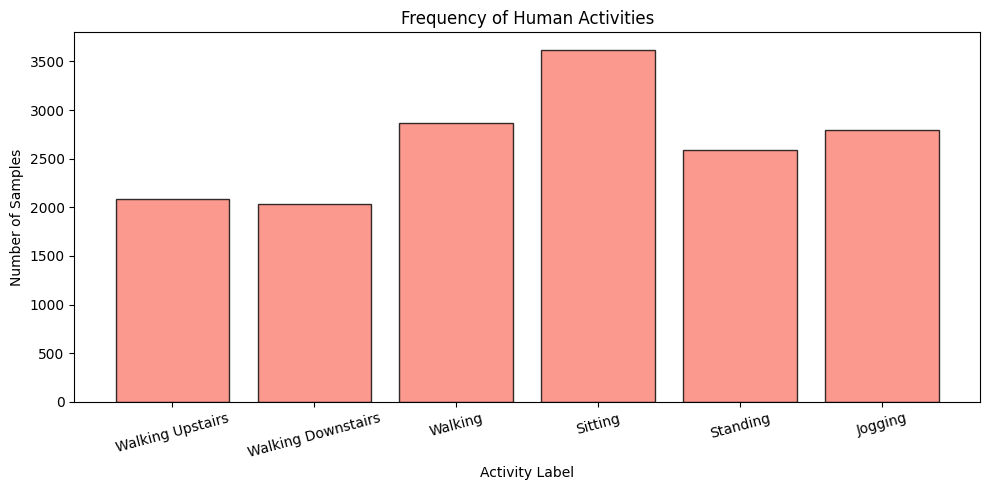

In [65]:
# Map your 0-5 index labels back to their text definitions for readability
activity_labels = [
    'Walking Upstairs',
    'Walking Downstairs',
    'Walking',
    'Sitting',
    'Standing',
    'Jogging'
]

# Count the occurrences of each class (0 through 5) in your dataset
unique_classes, counts = np.unique(y, return_counts=True)

# Plotting the class balance
plt.figure(figsize=(10, 5))
plt.bar(activity_labels, counts, color='salmon', edgecolor='black', alpha=0.8)
plt.title("Frequency of Human Activities")
plt.xlabel("Activity Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=15) # Rotates labels slightly so they don't overlap

plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

**A bar chart that counts the frequency of each activity class to see if the dataset is balanced.**

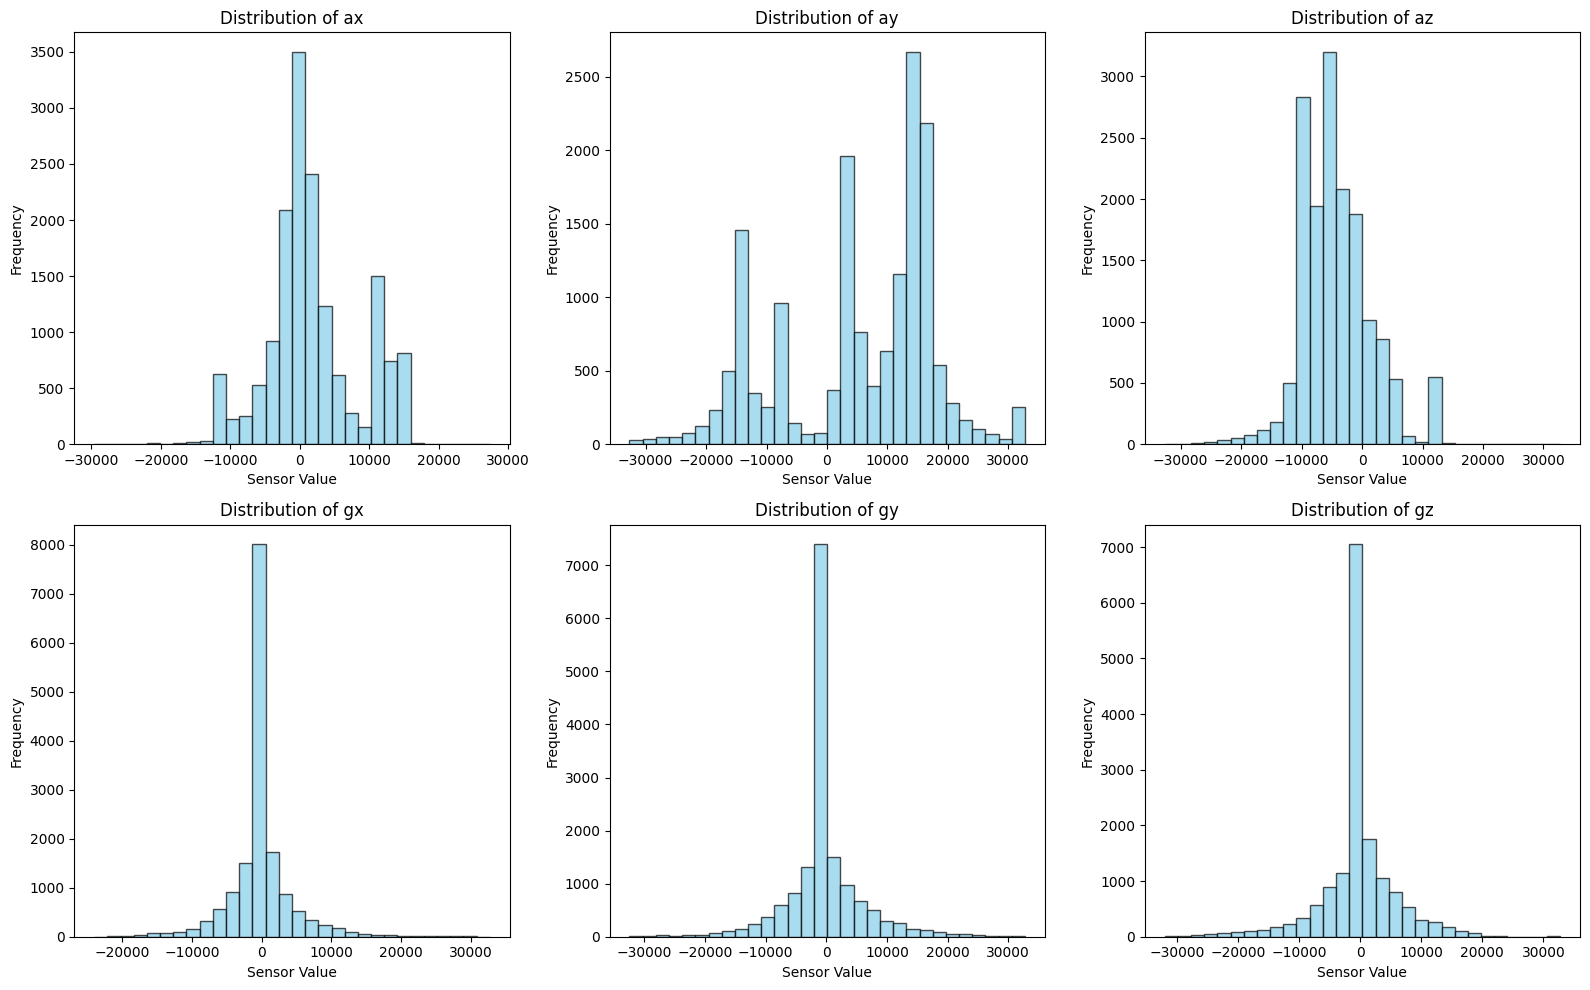

In [66]:
feature_names = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten() # Flatten into a 1D array to loop easily

# Plot a histogram for each of the 6 features
for i in range(6):
    axes[i].hist(x[:, i], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f"Distribution of {feature_names[i]}")
    axes[i].set_xlabel("Sensor Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("feature_distributions.png") # Saves the figure safely in Colab
plt.show()

**Model Definition**

Because this is a 6-label classification problem instead of the simpler 1 feature regression task with the sine wave, we need to update the model input shape and the output structure also.

6 neuron Input layer -> 32 neuron Hidden layer -> 16 neuron Hidden  layer -> 6 neuron Output Layer

In [67]:
# Updated model def for classifying 6 activities
activity_model = tf.keras.Sequential([
    tf.keras.Input(shape=(6,)), # Explicit Input layer
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(6, activation="softmax") # 6 classes output
])

activity_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Define the new enhanced model with dropout**

Dropout is a regularization technique used in neural networks to prevent overfitting. During training, it randomly sets a fraction of the neuron activations to zero at each update. This means that at each training step, a different subset of neurons is active, preventing any single neuron from becoming too reliant on others. This forces the network to learn more robust features that are useful even when some neurons are absent.

In the enhanced model, dropout layers were added to help the model generalize better to unseen data and avoid memorizing the training data, which often leads to poor performance on new examples.

In [68]:
# Enhanced model for classifying 6 activities with dropout
enhanced_activity_model = tf.keras.Sequential([
    tf.keras.Input(shape=(6,)), # Explicit Input layer for 6 features
    tf.keras.layers.Dense(64, activation="relu"), # More neurons in first layer
    tf.keras.layers.Dropout(0.3), # Dropout for regularization
    tf.keras.layers.Dense(32, activation="relu"), # Another hidden layer
    tf.keras.layers.Dropout(0.3), # Dropout for regularization
    tf.keras.layers.Dense(16, activation="relu"), # Third hidden layer
    tf.keras.layers.Dense(6, activation="softmax") # 6 classes output
])

enhanced_activity_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

enhanced_activity_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,158 (12.34 KB)

 Trainable params: 3,158 (12.34 KB)

 Non-trainable params: 0 (0.00 B)

**Train the Enhanced Activity Classification Model**

Now we will train this enhanced_activity_model using the scaled training and validation data.

In [69]:
history_enhanced = enhanced_activity_model.fit(
    X_train_scaled,
    y_train,
    batch_size=64,
    epochs=50,
    validation_data=(X_validate_scaled, y_validate)
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3653 - loss: 1.5167 - val_accuracy: 0.5766 - val_loss: 1.2900
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5358 - loss: 1.2220 - val_accuracy: 0.6273 - val_loss: 1.0441
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5912 - loss: 1.0587 - val_accuracy: 0.6448 - val_loss: 0.9218
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6119 - loss: 0.9739 - val_accuracy: 0.6717 - val_loss: 0.8717
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6228 - loss: 0.9364 - val_accuracy: 0.6785 - val_loss: 0.8511
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6346 - loss: 0.9103 - val_accuracy: 0.6836 - val_loss: 0.8287
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6413 - loss: 0.8969 - val_accuracy: 0.6923 - val_loss: 0.8118
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6516 - loss: 0.8744 - val_accuracy: 0.

**Visualize Training History of Enhanced Model**

Let's plot the training and validation accuracy and loss curves for the enhanced_activity_model to visually see its learning progress and potential overfitting.

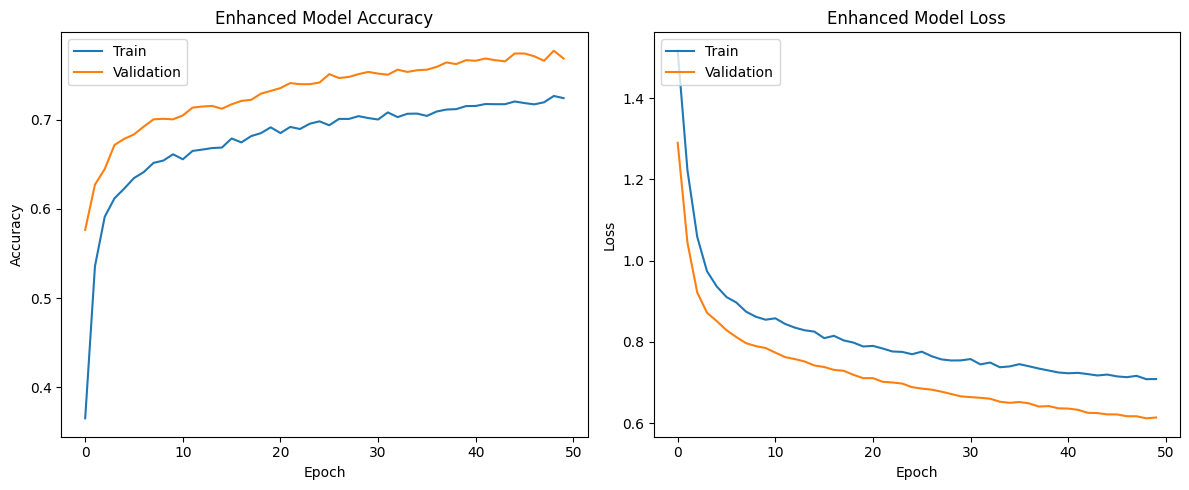

In [70]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_enhanced.history['accuracy'])
plt.plot(history_enhanced.history['val_accuracy'])
plt.title('Enhanced Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_enhanced.history['loss'])
plt.plot(history_enhanced.history['val_loss'])
plt.title('Enhanced Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

**Evaluate Enhanced Model Performance with Confusion Matrix**

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. It helps identify which activities are being confused by the model.



*   Rows: Represent the true labels (actual activities).

*   Columns: Represent the predicted labels (activities the model thought it was).
* Diagonal values: Show the number of correctly classified instances for each activity.
* Off-diagonal values: Indicate misclassifications, showing which activities are being confused with others.

By examining this matrix, you can identify which activities the model is performing well on and which ones it struggles with, giving insights into potential areas for further improvement.

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


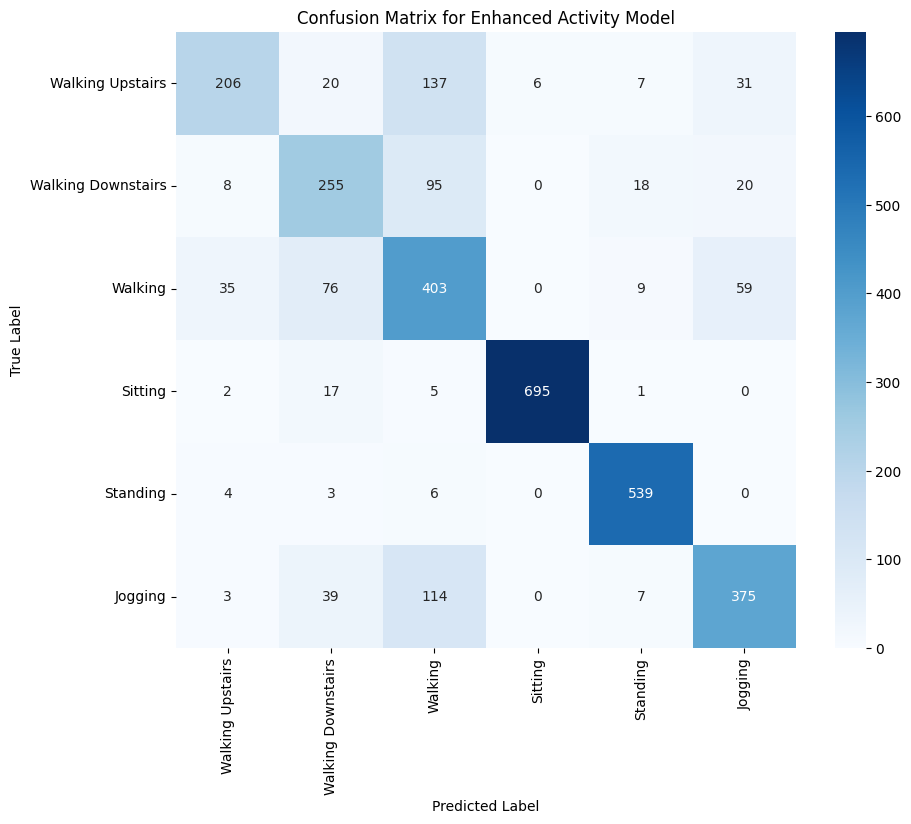

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Make predictions on the scaled test data
y_pred_enhanced_probs = enhanced_activity_model.predict(X_test_scaled)
y_pred_enhanced = np.argmax(y_pred_enhanced_probs, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_enhanced)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_labels, yticklabels=activity_labels)
plt.title('Confusion Matrix for Enhanced Activity Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Testing the Model**

In [72]:
from sklearn.metrics import classification_report

# Make predictions on the scaled test data using the original activity_model
y_pred_original_probs = activity_model.predict(X_test_scaled)
y_pred_original = np.argmax(y_pred_original_probs, axis=1)

# Generate a classification report
print("Classification Report for Original Activity Model:")
print(classification_report(y_test, y_pred_original, target_names=activity_labels))

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report for Original Activity Model:
                    precision    recall  f1-score   support

  Walking Upstairs       0.14      0.20      0.17       407
Walking Downstairs       0.16      0.09      0.12       396
           Walking       0.13      0.20      0.16       582
           Sitting       0.30      0.61      0.40       720
          Standing       0.00      0.00      0.00       552
           Jogging       1.00      0.01      0.01       538

          accuracy                           0.21      3195
         macro avg       0.29      0.19      0.14      3195
      weighted avg       0.30      0.21      0.16      3195



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Saving the keras model**

In [73]:
activity_model.save("enhanced_activity_model.keras")


**Converting the model to tflite**

In [74]:
converter = tf.lite.TFLiteConverter.from_keras_model(enhanced_activity_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
enhanced_activity_tflite_model = converter.convert()

Saved artifact at '/tmp/tmpswrkxacv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_45')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  135136588042448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135136588044176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135136588048784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135136588038800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135136588048016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135136588048400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135136588044944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135136588038416: TensorSpec(shape=(), dtype=tf.resource, name=None)


**Converting the model to the c, TFlite micro format for the microcontroller**

In [75]:
# Breaking the byte in several lines to fit better in the c header file
enhanced_activity_tflite_model_split_line = np.array_split([format(hex_value, '#04x') for hex_value in enhanced_activity_tflite_model], len(enhanced_activity_tflite_model)//8)

# Create the directory if it doesn't exist
import os
os.makedirs(C_HEADER_DIR, exist_ok=True)

# Write TfLite model to a C header file
open(f"{C_HEADER_DIR}{MODEL_FILE_NAME.lower()}.h", "w").write(
f"""
#ifndef {MODEL_FILE_NAME.upper()}_H
#define {MODEL_FILE_NAME.upper()}_H

const unsigned int {MODEL_FILE_NAME.lower()}_len = {len(enhanced_activity_tflite_model)};

const unsigned char {MODEL_FILE_NAME.lower()}[{len(enhanced_activity_tflite_model)}] = {{
    {",\n    ".join([", ".join(line) for line in enhanced_activity_tflite_model_split_line])}
}};

#endif // {MODEL_FILE_NAME.upper()}_H
"""
)
from google.colab import files

# Access the exact path where the script saved it
files.download(f"{C_HEADER_DIR}{MODEL_FILE_NAME.lower()}.h")

# Saving the TfLite model
open(f"{MODEL_FILE_NAME}.tflite", "wb").write(enhanced_activity_tflite_model)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

9424

**Testing the converted tflite model**

In [78]:
interpreter = tf.lite.Interpreter(model_path=f"{MODEL_FILE_NAME}.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_test_tflite_predict = []
for x_ in X_test_scaled:
  # Set input tensor
  # The model expects a 2D input (batch_size, features), so we use np.array([x_])
  # instead of np.array([[x_]]) to avoid an extra dimension.
  interpreter.set_tensor(input_details[0]['index'], np.array([x_], dtype=np.float32))

  # Run the inference
  interpreter.invoke()

  y_test_tflite_predict.append(interpreter.get_tensor(output_details[0]['index']))

y_test_tflite_predict = np.array(y_test_tflite_predict)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


**Comparison of the Keras enhanced model and the TFLite converted model**

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Keras Enhanced Model Accuracy: 0.7740
TFLite Converted Model Accuracy: 0.7746


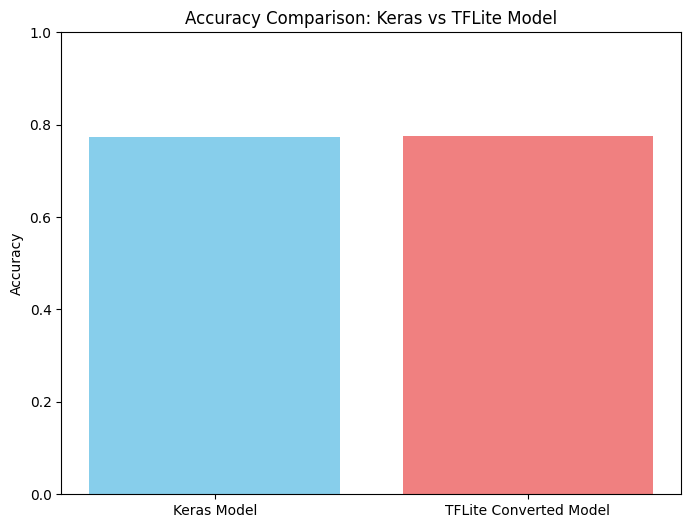

In [80]:
from sklearn.metrics import accuracy_score

# Predictions from the Keras enhanced model
y_pred_keras_probs = enhanced_activity_model.predict(X_test_scaled)
y_pred_keras = np.argmax(y_pred_keras_probs, axis=1)

# Predictions from the TFLite model
# y_test_tflite_predict contains predictions for each sample as an array of shape (1, 6)
# We need to remove the extra dimension and then get the argmax
y_test_tflite_predict_squeezed = np.squeeze(y_test_tflite_predict, axis=1)
y_pred_tflite = np.argmax(y_test_tflite_predict_squeezed, axis=1)

# Calculate accuracy for both models
accuracy_keras = accuracy_score(y_test, y_pred_keras)
accuracy_tflite = accuracy_score(y_test, y_pred_tflite)

print(f"Keras Enhanced Model Accuracy: {accuracy_keras:.4f}")
print(f"TFLite Converted Model Accuracy: {accuracy_tflite:.4f}")

# Plotting comparison of accuracies
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(["Keras Model", "TFLite Converted Model"], [accuracy_keras, accuracy_tflite], color=['skyblue', 'lightcoral'])
ax.set_title("Accuracy Comparison: Keras vs TFLite Model")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1) # Accuracy is between 0 and 1
plt.show()